## An Application with APRIORI on real data

In [3]:
!pip install -q apyori
!pip install -q pandas pyfim


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# setup
# this script is assuming that the apyori.py and pyfim.py scripts (along with the data) are uploaded
import pandas as pd
import numpy as np
from apyori import apriori
from fim import eclat
import matplotlib.pyplot as plt

In [5]:
order_data = pd.read_csv('https://raw.githubusercontent.com/yanhai-xiong/DATA301-AML/main/Data%20Sets/order_products_train.csv?raw=true')
product_data = pd.read_csv('https://raw.githubusercontent.com/yanhai-xiong/DATA301-AML/main/Data%20Sets/products.csv')

In [6]:
order_data

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1
...,...,...,...,...
1384612,3421063,14233,3,1
1384613,3421063,35548,4,1
1384614,3421070,35951,1,1
1384615,3421070,16953,2,1


In [7]:
product_data.loc[product_data.product_id==49302]

,product_id,product_name,aisle_id,department_id
49301,49302,Bulgarian Yogurt,120,16


In [8]:
# here we merged the two data sets for connecting the barcode with the name of the actual product
# we save the result into a new data frame called named_orders
named_orders = pd.merge(order_data,product_data,on='product_id')
named_orders.sort_values('product_id')

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
666335,1639546,1,10,1,Chocolate Sandwich Cookies,61,19
1188548,2936483,1,9,1,Chocolate Sandwich Cookies,61,19
855368,2111236,1,3,1,Chocolate Sandwich Cookies,61,19
771078,1897200,1,24,1,Chocolate Sandwich Cookies,61,19
1109911,2742935,1,2,1,Chocolate Sandwich Cookies,61,19
...,...,...,...,...,...,...,...
446055,1092104,49687,1,0,Smartblend Healthy Metabolism Dry Cat Food,41,8
891142,2198380,49688,10,0,Fresh Foaming Cleanser,73,11
269349,655800,49688,10,1,Fresh Foaming Cleanser,73,11
1209047,2986153,49688,16,0,Fresh Foaming Cleanser,73,11


In [9]:
# get the count for the different products purchased
counts = named_orders['product_name'].value_counts()
# we want items transacted at least 500 times
counts.head(370)

product_name
Banana                        18726
Bag of Organic Bananas        15480
Organic Strawberries          10894
Organic Baby Spinach           9784
Large Lemon                    8135
                              ...  
Organic Chicken Stock           508
Uncured Slow Cooked Ham         508
Strawberry Rhubarb Yoghurt      507
Blueberry Yoghurt               506
Tomato Paste                    503
Name: count, Length: 370, dtype: int64

In [10]:
# here we create a hard threshold for the frequency of products being transacted
v = 500

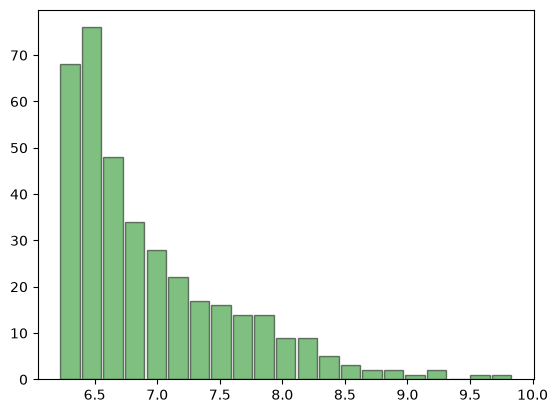

In [11]:
# we can visualize this the frequency distribution as a histogram and retain a list with the most frequently purchased
counts = counts[counts > v] # this is the thresholding part
plt.hist(np.log(counts.values), bins=21,color='green',edgecolor='k',rwidth=0.9,alpha=0.5)
plt.show()

In [12]:
counts

product_name
Banana                            18726
Bag of Organic Bananas            15480
Organic Strawberries              10894
Organic Baby Spinach               9784
Large Lemon                        8135
                                  ...  
Strawberry Rhubarb Yoghurt          507
Blueberry Yoghurt                   506
Tomato Paste                        503
Cran Raspberry Sparkling Water      503
Organic Red Delicious Apple         501
Name: count, Length: 372, dtype: int64

In [28]:
# IMPORTANT
# here we subset the "selected" orders
selected_orders = named_orders[named_orders['product_name'].isin(counts.index.values.tolist())]
selected_orders

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
2,1,10246,3,0,Organic Celery Hearts,83,4
3,1,49683,4,0,Cucumber Kirby,83,4
5,1,13176,6,0,Bag of Organic Bananas,24,4
6,1,47209,7,0,Organic Hass Avocado,24,4
7,1,22035,8,1,Organic Whole String Cheese,21,16
...,...,...,...,...,...,...,...
1384599,3421056,21709,3,1,Sparkling Lemon Water,115,7
1384610,3421063,49235,1,1,Organic Half & Half,53,16
1384612,3421063,14233,3,1,Natural Artesian Water,115,7
1384614,3421070,35951,1,1,Organic Unsweetened Almond Milk,91,16


In [29]:
# here we pivot the data frame to see the products transacted in each purchase order
pd.options.mode.chained_assignment = None
selected_orders['cols'] = selected_orders.groupby('order_id').cumcount()
selected_pivot = selected_orders.pivot(index = 'order_id',columns = 'cols')[['product_name']]

In [30]:
selected_pivot

product_name  \
cols                                                     0    
order_id                                                      
1                                     Organic Celery Hearts   
36                                             Spring Water   
38                                     Organic Baby Arugula   
96                                         Organic Cucumber   
98                                     Natural Spring Water   
...                                                     ...   
3421026   Organic Sticks Low Moisture Part Skim Mozzarel...   
3421049                               Organic Baby Broccoli   
3421056                               Sparkling Lemon Water   
3421063                                 Organic Half & Half   
3421070                     Organic Unsweetened Almond Milk   

                                                                   \
cols                          1                                2    
order_id                                                            
1                 Cucumber Kirby           Bag of Organic Bananas   
36           Organic Half & Half               Super Greens Salad   
38              Bunched Cilantro              Flat Parsley, Bunch   
96        Organic Grape Tomatoes              Organic Raspberries   
98        Bag of Organic Bananas  Organic Unsweetened Almond Milk   
...                          ...                              ...   
3421026                      NaN                              NaN   
3421049                      NaN                              NaN   
3421056                      NaN                              NaN   
3421063   Natural Artesian Water                              NaN   
3421070     Creamy Peanut Butter                              NaN   

                                                                          \
cols                                     3                            4    
order_id                                                                   
1                      Organic Hass Avocado  Organic Whole String Cheese   
36        Organic Garnet Sweet Potato (Yam)                    Asparagus   
38                                      NaN                          NaN   
96               Organic Whole Strawberries          Organic Blueberries   
98                      Organic Raspberries                    Guacamole   
...                                     ...                          ...   
3421026                                 NaN                          NaN   
3421049                                 NaN                          NaN   
3421056                                 NaN                          NaN   
3421063                                 NaN                          NaN   
3421070                                 NaN                          NaN   

                                                       \
cols               5                               6    
order_id                                                
1                 NaN                             NaN   
36                NaN                             NaN   
38                NaN                             NaN   
96                NaN                             NaN   
98        Black Beans  Organic Raw Kombucha Gingerade   
...               ...                             ...   
3421026           NaN                             NaN   
3421049           NaN                             NaN   
3421056           NaN                             NaN   
3421063           NaN                             NaN   
3421070           NaN                             NaN   

                                                                            \
cols                              7                     8               9    
order_id                                                                     
1                                NaN                   NaN             NaN   
36                   

In [17]:
# the total number of different products if we threshold at v
len(selected_pivot.columns)

34

In [32]:
purchases = (
    selected_pivot
    .astype(str)
    .to_numpy()
    .tolist()
)

In [36]:
purchases[:2]

[['Organic Celery Hearts',
  'Cucumber Kirby',
  'Bag of Organic Bananas',
  'Organic Hass Avocado',
  'Organic Whole String Cheese',
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan],
 ['Spring Water',
  'Organic Half & Half',
  'Super Greens Salad',
  'Organic Garnet Sweet Potato (Yam)',
  'Asparagus',
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan]]

In [35]:
# we want to clean the names so 'nan' does no longer appear
# we want a clean list of transactions that is without any "nan" items
cleanList = []
for purchase in purchases:
  cleanList.append([x for x in purchase if str(x) != 'nan'])

In [37]:
cleanList[0]

['Organic Celery Hearts',
 'Cucumber Kirby',
 'Bag of Organic Bananas',
 'Organic Hass Avocado',
 'Organic Whole String Cheese']

In [104]:
# we are providing the clean list to the "apriori" algorithm
rules = apriori(cleanList, min_support = 0.005, min_confidence = 0.3, min_lift=2,max_length=3)
rules = [rule for rule in rules if len(rule.items) == 3]

In [105]:
l = list(rules)
l

[RelationRecord(items=frozenset({'Organic Baby Spinach', 'Bag of Organic Bananas', 'Organic Strawberries'}), support=0.005311784560533531, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Organic Baby Spinach', 'Organic Strawberries'}), items_add=frozenset({'Bag of Organic Bananas'}), confidence=0.3581452104942037, lift=2.556735727810333)]),
 RelationRecord(items=frozenset({'Bag of Organic Bananas', 'Organic Hass Avocado', 'Organic Strawberries'}), support=0.006424816078328462, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Organic Hass Avocado', 'Organic Strawberries'}), items_add=frozenset({'Bag of Organic Bananas'}), confidence=0.4613385315139701, lift=3.2934147144106793)]),
 RelationRecord(items=frozenset({'Organic Raspberries', 'Bag of Organic Bananas', 'Organic Strawberries'}), support=0.005872824837796017, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Organic Raspberries', 'Bag of Organic Bananas'}), items_add=frozenset({'Organic Strawberrie

In [108]:
l[0]

RelationRecord(items=frozenset({'Organic Baby Spinach', 'Bag of Organic Bananas', 'Organic Strawberries'}), support=0.005311784560533531, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Organic Baby Spinach', 'Organic Strawberries'}), items_add=frozenset({'Bag of Organic Bananas'}), confidence=0.3581452104942037, lift=2.556735727810333)])

In [106]:
rules = 0
for result in l:
  supp   = int(result.support*10000)/100
  if len(result.ordered_statistics)>1 and result.ordered_statistics[0].confidence < result.ordered_statistics[1].confidence:
    i = 1
  else:
    i = 0
  conf   = int(result.ordered_statistics[i].confidence*100)
  hypo   = ''.join([x+' ' for x in result.ordered_statistics[i].items_base])
  conc   = ''.join([x+' ' for x in result.ordered_statistics[i].items_add])
  rules = rules + 1
  print("If "+str(hypo)+" is purchased, " +str(conf)+" % of the time " + str(conc)+" is purchased [support - " +
        str(supp)+"%]"+'  Lift: '+str(round(result.ordered_statistics[i].lift,2)))
print("Total rules built : " +str(rules))

If Organic Baby Spinach Organic Strawberries  is purchased, 35 % of the time Bag of Organic Bananas  is purchased [support - 0.53%]  Lift: 2.56
If Organic Hass Avocado Organic Strawberries  is purchased, 46 % of the time Bag of Organic Bananas  is purchased [support - 0.64%]  Lift: 3.29
If Organic Raspberries Organic Strawberries  is purchased, 38 % of the time Bag of Organic Bananas  is purchased [support - 0.58%]  Lift: 2.77
Total rules built : 3


In [107]:
nr = 0
confidence = []
lift = []
for item in l:
    pair = item[0]
    # We cannot seem to tell apriori to ignore NaN items, so we will refrain from printing results containing them
    # they will be returned as lower-case text "nan".
    if "nan" not in pair:
        if len(item[2])==1 or item[2][0][2] > item[2][1][2]:
          items = [x for x in pair]
          print("Rule: " + items[0] + " => " + items[1])

          #second index of the inner list
          print("Support: " + str(round(item[1]*100,2)) + "%")

          #third index of the list located at 0th
          #of the third index of the inner list
          confidence.append(round( item[2][0][2]*100,2))
          print("Confidence: " + str(round( item[2][0][2]*100,2)) + "%")
          lift.append(round( item[2][0][2]*100,2))
          print("Lift: " + str( round(item[2][0][3],2) ))
          nr += 1
        else:
          items = [x for x in pair]
          print("Rule: " + items[1] + " => " + items[0])

          #second index of the inner list
          print("Support: " + str(round(item[1]*100,2)) + "%")

          #third index of the list located at 0th
          #of the third index of the inner list
          confidence.append(round( item[2][1][2]*100,2))
          print("Confidence: " + str(round( item[2][1][2]*100,2)) + "%")
          lift.append(round( item[2][1][2]*100,2))
          print("Lift: " + str( round(item[2][1][3],2) ))
          nr += 1

Rule: Organic Baby Spinach => Bag of Organic Bananas
Support: 0.53%
Confidence: 35.81%
Lift: 2.56
Rule: Bag of Organic Bananas => Organic Hass Avocado
Support: 0.64%
Confidence: 46.13%
Lift: 3.29
Rule: Bag of Organic Bananas => Organic Raspberries
Support: 0.59%
Confidence: 38.86%
Lift: 2.77


In [102]:
items[0]

'Organic Raspberries'

## Example for the ECLAT algorithm in Python with real data

In [197]:
rule_count = 0
rules = eclat(cleanList, supp=2, zmin=2)
for i in range(0,len(rules)):
    supp = round(int(rules[i][1])/len(cleanList)*100,3)
    items = rules[i][0]
    if "nan" not in items:
        rule_count = rule_count +1
        item_1 = rules[i][0][0]
        item_2 = rules[i][0][1]
        print("If "+str(item_1)+" is purchased, "+str(supp)+"% of the time " + str(item_2)+" is purchased [absolute support=" +str(rules[i][1])+"]")
print("Total rules built : " +str(rule_count))

If Organic Strawberries is purchased, 2.782% of the time Bag of Organic Bananas is purchased [absolute support=3074]
If Organic Baby Spinach is purchased, 2.023% of the time Bag of Organic Bananas is purchased [absolute support=2236]
If Organic Avocado is purchased, 2.005% of the time Banana is purchased [absolute support=2216]
If Organic Hass Avocado is purchased, 2.19% of the time Bag of Organic Bananas is purchased [absolute support=2420]
Total rules built : 4


In [201]:
rules_e = eclat(cleanList, supp=2, zmin=2)
eclat_final = [];
for item in rules_e:
    pair = item[0]
    if "nan" not in pair:
        #print(pair)
        eclat_final.append([item[0][0], item[0][1], item[1]])
eclat_final = pd.DataFrame(eclat_final, columns = ['Item1', 'Item2', 'Support'])
eclat_final.sort_values(by=['Support'],ascending=False)

,Item1,Item2,Support
0,Organic Strawberries,Bag of Organic Bananas,3074
3,Organic Hass Avocado,Bag of Organic Bananas,2420
1,Organic Baby Spinach,Bag of Organic Bananas,2236
2,Organic Avocado,Banana,2216


In [204]:
from mlxtend.frequent_patterns import association_rules

### Practice
Use the association_rules to analyze rules from frequent itesets

In [202]:
frequent_items = eclat(cleanList, supp=2, zmin=1)

In [203]:
frequent_items

[(('Banana',), 18726),
 (('Bag of Organic Bananas',), 15480),
 (('Organic Strawberries', 'Bag of Organic Bananas'), 3074),
 (('Organic Strawberries',), 10894),
 (('Organic Baby Spinach', 'Bag of Organic Bananas'), 2236),
 (('Organic Baby Spinach',), 9784),
 (('Large Lemon',), 8135),
 (('Organic Avocado', 'Banana'), 2216),
 (('Organic Avocado',), 7409),
 (('Organic Hass Avocado', 'Bag of Organic Bananas'), 2420),
 (('Organic Hass Avocado',), 7293),
 (('Strawberries',), 6494),
 (('Limes',), 6033),
 (('Organic Raspberries',), 5546),
 (('Organic Blueberries',), 4966),
 (('Organic Whole Milk',), 4908),
 (('Organic Cucumber',), 4613),
 (('Organic Zucchini',), 4589),
 (('Organic Yellow Onion',), 4290),
 (('Organic Garlic',), 4158),
 (('Seedless Red Grapes',), 4059),
 (('Asparagus',), 3868),
 (('Organic Grape Tomatoes',), 3823),
 (('Organic Red Onion',), 3818),
 (('Yellow Onions',), 3762),
 (('Organic Baby Carrots',), 3597),
 (('Honeycrisp Apple',), 3551),
 (('Organic Cilantro',), 3526),
 (('O

In [205]:
frequent_df = pd.DataFrame(
    [(support/len(cleanList), frozenset(items)) for items, support in frequent_items],
    columns=['support', 'itemsets']
)

frequent_df.head()

,support,itemsets
0,0.169452,(Banana)
1,0.140079,(Bag of Organic Bananas)
2,0.027817,"(Bag of Organic Bananas, Organic Strawberries)"
3,0.098580,(Organic Strawberries)
4,0.020234,"(Organic Baby Spinach, Bag of Organic Bananas)"


In [207]:
rules = association_rules(
    frequent_df,
    metric="confidence",
    min_threshold=0.2
)

In [208]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Organic Strawberries),(Bag of Organic Bananas),0.098580,0.140079,0.027817,0.282174,2.014388,1.0,0.014008,1.197951,0.558642,0.131931,0.165241,0.240376
1,(Organic Baby Spinach),(Bag of Organic Bananas),0.088536,0.140079,0.020234,0.228536,1.631481,1.0,0.007832,1.114662,0.424657,0.097099,0.102867,0.186490
2,(Organic Avocado),(Banana),0.067044,0.169452,0.020053,0.299096,1.765073,1.0,0.008692,1.184966,0.464600,0.092646,0.156094,0.208717
3,(Organic Hass Avocado),(Bag of Organic Bananas),0.065995,0.140079,0.021899,0.331825,2.368841,1.0,0.012654,1.286970,0.618682,0.118901,0.222981,0.244078


## Examples with Gradient Descent

In [2]:
# include a setup for plotting
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
# import a real data to demonstrate gradient descent
data = pd.read_csv('https://raw.githubusercontent.com/yanhai-xiong/DATA301-AML/main/Data%20Sets/Advertising.csv?raw=true')

In [52]:
# here the goal is to predict the Sales (cont. variable) by using values from TV, Radio and Newspaper advertising
x = data.loc[:,['TV','Radio','Newspaper']].values
y = data['Sales'].values

In [54]:
# first we want to center the data, and then we want to find the optimal weights for a linear model, i.e. minimize the sum of squared errors
# we may need a scaler
def zscore(x):
    return (x-np.mean(x,axis=0))/np.std(x,axis=0)

In [55]:
xscaled = zscore(x)
ycentered = y-np.mean(y)

In [58]:
# we look for the optimal weights w1, w2 and w3 such that the predictions made with the corresponding linear combination of the columns is minimizing SSE
# define the loss function
def L(w):
    prediction = xscaled@w
    errors = y - prediction
    return sum((errors**2))/len(errors)

In [59]:
L([1,2,3])
# we need better weights so we must compute the gradient of L

np.float64(215.2580894614986)

In [65]:
def gradient(w):
    prediction = xscaled@w
    errors = y - prediction
    return -1/len(errors)*errors@xscaled

In [66]:
gradient([1,2,3])

array([-2.79144517,  0.11822912,  2.5766967 ])

In [71]:
w_new = w - 0.1 *gradient(w)

In [72]:
# this shows that at the updated weights (w_new) the loss function value has decreased.
L(w_new)

np.float64(212.50708921790113)